In [2]:
import pandas as pd

df = pd.read_csv('flood_final_dataset.csv')
df.head()

,time,precipitation_sum,temperature_2m_max,temperature_2m_min,et0_fao_evapotranspiration,rain_sum,precipitation_hours,river_discharge,temperature_2m_mean,dewpoint_2m_max,...,soil_saturation,day_of_year,month,day_sin,day_cos,month_sin,month_cos,is_monsoon,days_since_rain,flood_risk
0,2010-01-30,0.0,26.9,14.5,3.92,0.0,0.0,0.20,20.8,12.5,...,0.262292,30,1,0.493776,0.869589,0.500000,0.866025,0,18,0
1,2010-01-31,0.0,26.9,13.3,4.20,0.0,0.0,0.20,20.4,11.9,...,0.261604,31,1,0.508671,0.860961,0.500000,0.866025,0,19,0
2,2010-02-01,0.0,26.5,13.9,3.71,0.0,0.0,0.23,20.5,11.7,...,0.260854,32,2,0.523416,0.852078,0.866025,0.500000,0,20,0
3,2010-02-02,0.0,25.5,14.5,3.26,0.0,0.0,0.25,19.7,11.7,...,0.260958,33,2,0.538005,0.842942,0.866025,0.500000,0,21,0
4,2010-02-03,0.0,26.2,15.0,3.97,0.0,0.0,0.25,20.5,11.0,...,0.260771,34,2,0.552435,0.833556,0.866025,0.500000,0,22,0


In [3]:
df.shape

(5864, 34)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5864 entries, 0 to 5863
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   time                         5864 non-null   object 
 1   precipitation_sum            5864 non-null   float64
 2   temperature_2m_max           5864 non-null   float64
 3   temperature_2m_min           5864 non-null   float64
 4   et0_fao_evapotranspiration   5864 non-null   float64
 5   rain_sum                     5864 non-null   float64
 6   precipitation_hours          5864 non-null   float64
 7   river_discharge              5864 non-null   float64
 8   temperature_2m_mean          5864 non-null   float64
 9   dewpoint_2m_max              5864 non-null   float64
 10  dewpoint_2m_min              5864 non-null   float64
 11  wind_speed_10m_max           5864 non-null   float64
 12  wind_gusts_10m_max           5864 non-null   float64
 13  wind_direction_10m

In [5]:
import pandas as pd
import numpy as np

# ── Load final dataset ──
df = pd.read_csv("flood_final_dataset.csv", parse_dates=["time"])

# ── Create Flood Risk Label ──
# Based on 3 key indicators:
# 1. precipitation_sum   → how much rain today
# 2. rainfall_3d         → how much rain in last 3 days (soil saturation)
# 3. river_discharge     → how high is the river

def assign_flood_risk(row):
    rain       = row["precipitation_sum"]
    rain_3d    = row["rainfall_3d"]
    discharge  = row["river_discharge"]
    soil       = row["soil_saturation"]

    # ── EXTREME: Heavy rain + saturated soil + high river ──
    if (rain >= 50 and rain_3d >= 100 and discharge >= 50):
        return 3  # Extreme

    # ── HIGH: Significant rain + elevated river ──
    elif (rain >= 25 and rain_3d >= 60) or (discharge >= 30 and rain >= 20):
        return 2  # High

    # ── MEDIUM: Moderate rain or elevated soil moisture ──
    elif (rain >= 10 and rain_3d >= 25) or (soil >= 0.3 and rain >= 8):
        return 1  # Medium

    # ── LOW: Normal conditions ──
    else:
        return 0  # Low

df["flood_risk"] = df.apply(assign_flood_risk, axis=1)

# ── Check label distribution ──
print("Flood Risk Label Distribution:")
label_map = {0: "Low", 1: "Medium", 2: "High", 3: "Extreme"}
counts = df["flood_risk"].value_counts().sort_index()
for k, v in counts.items():
    pct = v / len(df) * 100
    print(f"  {k} - {label_map[k]:8s}: {v:5d} rows  ({pct:.1f}%)")

# ── Save ──
df.to_csv("flood_final_dataset.csv", index=False)
print(f"\nDataset saved with flood_risk column.")
print(f"Shape: {df.shape}")
 

Flood Risk Label Distribution:
  0 - Low     :  5113 rows  (87.2%)
  1 - Medium  :   613 rows  (10.5%)
  2 - High    :   138 rows  (2.4%)

Dataset saved with flood_risk column.
Shape: (5864, 34)


In [6]:
df.head()

,time,precipitation_sum,temperature_2m_max,temperature_2m_min,et0_fao_evapotranspiration,rain_sum,precipitation_hours,river_discharge,temperature_2m_mean,dewpoint_2m_max,...,soil_saturation,day_of_year,month,day_sin,day_cos,month_sin,month_cos,is_monsoon,days_since_rain,flood_risk
0,2010-01-30,0.0,26.9,14.5,3.92,0.0,0.0,0.20,20.8,12.5,...,0.262292,30,1,0.493776,0.869589,0.500000,0.866025,0,18,0
1,2010-01-31,0.0,26.9,13.3,4.20,0.0,0.0,0.20,20.4,11.9,...,0.261604,31,1,0.508671,0.860961,0.500000,0.866025,0,19,0
2,2010-02-01,0.0,26.5,13.9,3.71,0.0,0.0,0.23,20.5,11.7,...,0.260854,32,2,0.523416,0.852078,0.866025,0.500000,0,20,0
3,2010-02-02,0.0,25.5,14.5,3.26,0.0,0.0,0.25,19.7,11.7,...,0.260958,33,2,0.538005,0.842942,0.866025,0.500000,0,21,0
4,2010-02-03,0.0,26.2,15.0,3.97,0.0,0.0,0.25,20.5,11.0,...,0.260771,34,2,0.552435,0.833556,0.866025,0.500000,0,22,0


In [7]:
df.isnull().sum()

time                           0
precipitation_sum              0
temperature_2m_max             0
temperature_2m_min             0
et0_fao_evapotranspiration     0
rain_sum                       0
precipitation_hours            0
river_discharge                0
temperature_2m_mean            0
dewpoint_2m_max                0
dewpoint_2m_min                0
wind_speed_10m_max             0
wind_gusts_10m_max             0
wind_direction_10m_dominant    0
shortwave_radiation_sum        0
soil_moisture_0_to_7cm         0
soil_moisture_7_to_28cm        0
soil_moisture_28_to_100cm      0
rainfall_3d                    0
rainfall_7d                    0
rainfall_14d                   0
rainfall_30d                   0
rainfall_intensity             0
humidity                       0
soil_saturation                0
day_of_year                    0
month                          0
day_sin                        0
day_cos                        0
month_sin                      0
month_cos 

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

 

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.1)
  from scipy.stats import gaussian_kde


In [9]:
# sns.heatmap(df.select_dtypes(include=['number']), annot=True)

In [10]:
df.describe()

,time,precipitation_sum,temperature_2m_max,temperature_2m_min,et0_fao_evapotranspiration,rain_sum,precipitation_hours,river_discharge,temperature_2m_mean,dewpoint_2m_max,...,soil_saturation,day_of_year,month,day_sin,day_cos,month_sin,month_cos,is_monsoon,days_since_rain,flood_risk
count,5864,5864.000000,5864.000000,5864.000000,5864.000000,5864.000000,5864.000000,5864.000000,5864.000000,5864.000000,...,5864.000000,5864.000000,5864.000000,5864.000000,5864.000000,5.864000e+03,5.864000e+03,5864.000000,5864.000000,5864.000000
mean,2018-02-08 12:00:00,3.570822,30.734226,20.273397,4.748675,3.570822,3.544168,0.876332,25.185931,16.459908,...,0.328332,182.635402,6.507162,0.002146,0.003321,-1.939473e-03,-1.917387e-04,0.332879,22.017735,0.151603
min,2010-01-30 00:00:00,0.000000,17.000000,5.100000,0.470000,0.000000,0.000000,0.200000,11.200000,-2.500000,...,0.212292,1.000000,1.000000,-0.999991,-0.999963,-1.000000e+00,-1.000000e+00,0.000000,0.000000,0.000000
25%,2014-02-03 18:00:00,0.000000,27.100000,15.600000,3.290000,0.000000,0.000000,0.250000,21.575000,11.500000,...,0.258599,91.000000,4.000000,-0.705584,-0.708627,-8.660254e-01,-8.660254e-01,0.000000,0.000000,0.000000
50%,2018-02-08 12:00:00,0.000000,29.800000,22.000000,4.180000,0.000000,0.000000,0.280000,25.400000,15.800000,...,0.282687,182.500000,7.000000,0.008607,0.004304,-2.449294e-16,6.123234e-17,0.000000,10.000000,0.000000
75%,2022-02-13 06:00:00,1.300000,34.000000,24.000000,5.960000,1.300000,5.000000,0.830000,28.100000,22.700000,...,0.401125,274.000000,10.000000,0.705584,0.714673,5.000000e-01,8.660254e-01,1.000000,32.000000,0.000000
max,2026-02-18 00:00:00,283.600000,45.500000,32.600000,12.760000,283.600000,24.000000,19.840000,38.500000,26.400000,...,0.517250,366.000000,12.000000,0.999991,1.000000,1.000000e+00,1.000000e+00,1.000000,144.000000,2.000000
std,NaN,11.181448,5.337122,5.616422,2.175997,11.181448,6.313577,1.306873,5.250341,5.995223,...,0.089104,105.600761,3.453690,0.706675,0.707648,7.063198e-01,7.080107e-01,0.471284,29.053176,0.419185


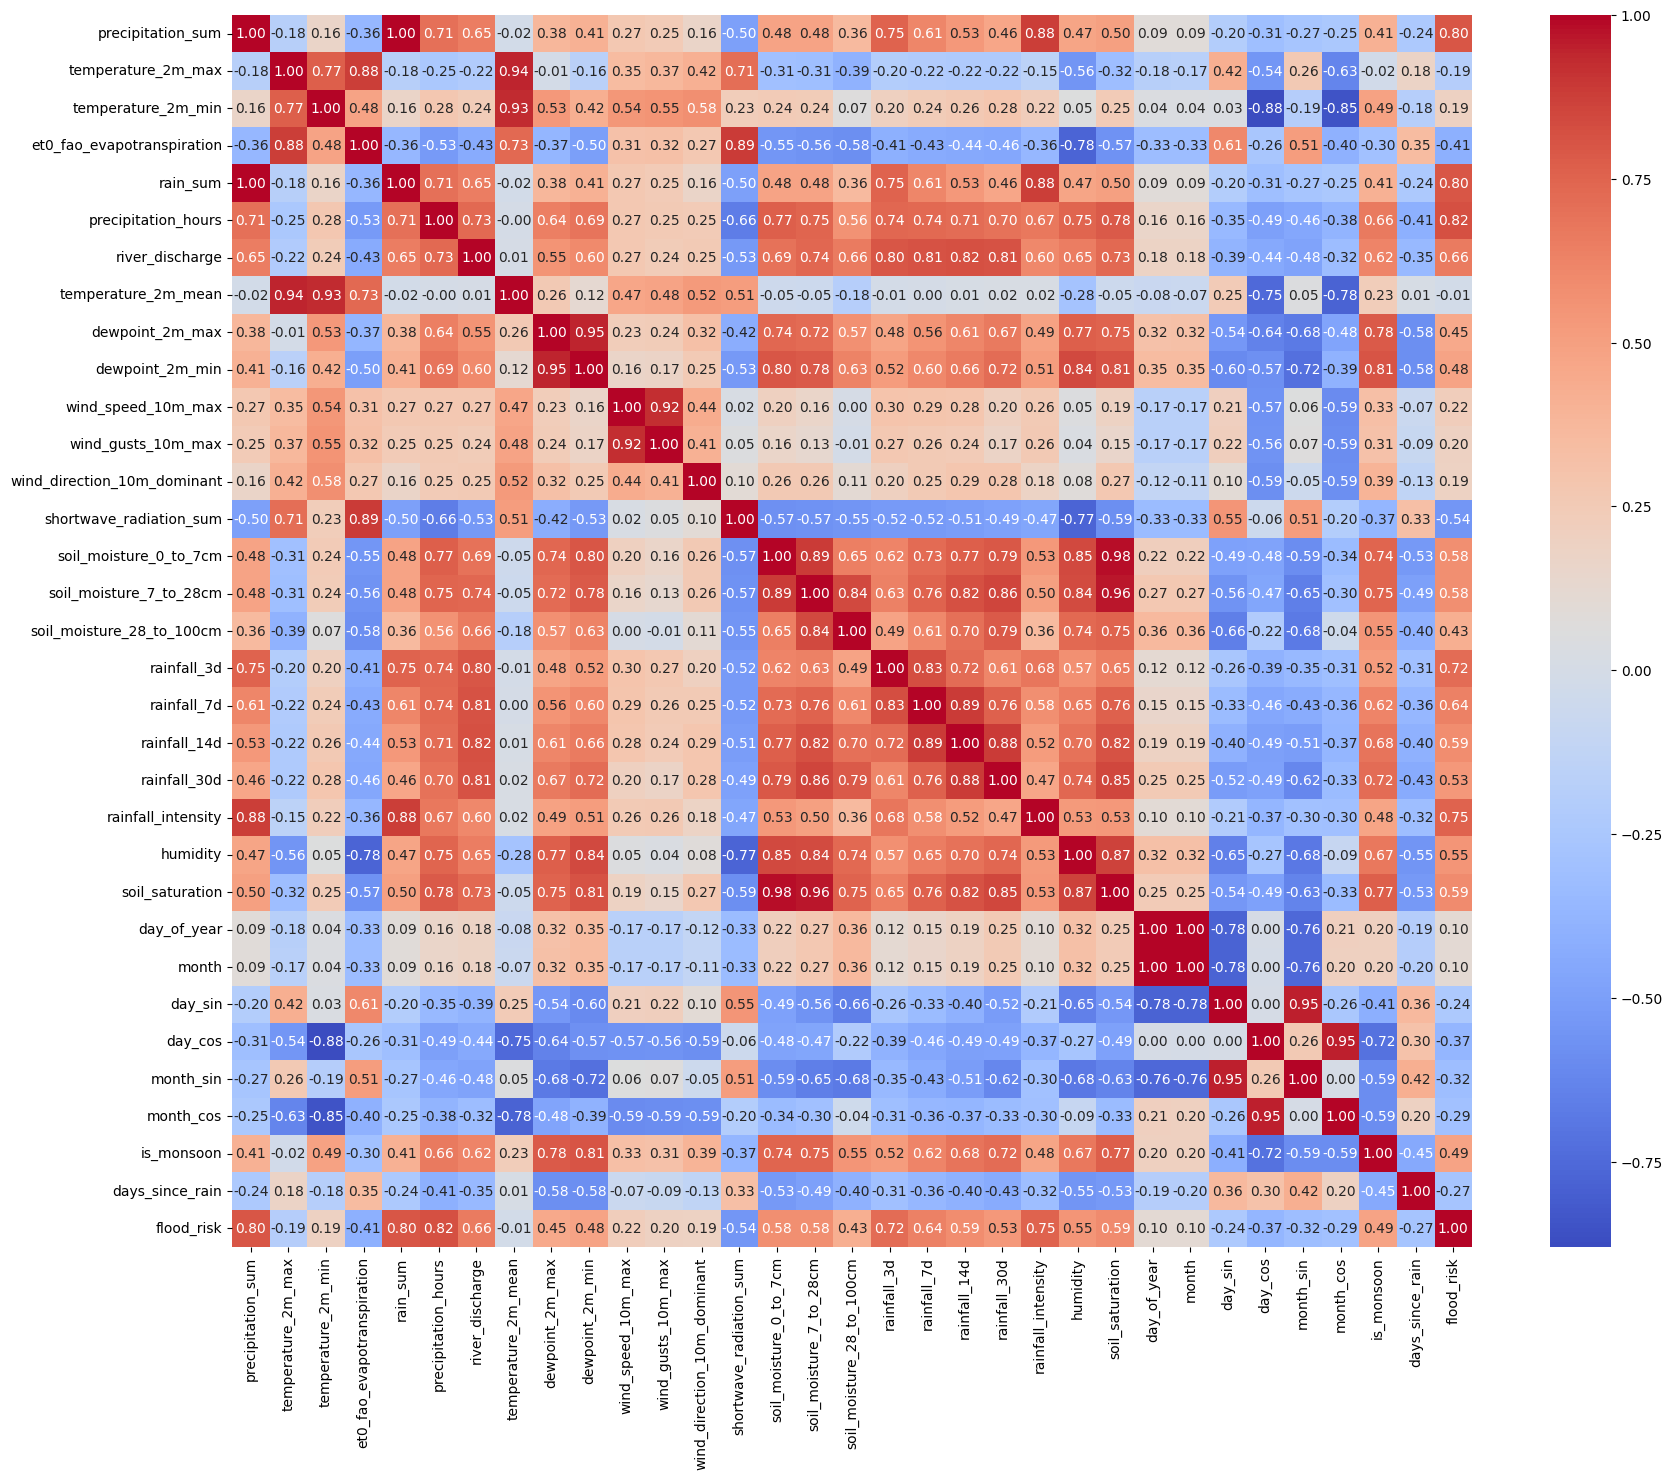

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(20,16))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [12]:
df.select_dtypes(include=['number']).corr()

,precipitation_sum,temperature_2m_max,temperature_2m_min,et0_fao_evapotranspiration,rain_sum,precipitation_hours,river_discharge,temperature_2m_mean,dewpoint_2m_max,dewpoint_2m_min,...,soil_saturation,day_of_year,month,day_sin,day_cos,month_sin,month_cos,is_monsoon,days_since_rain,flood_risk
precipitation_sum,1.000000,-0.180624,0.163297,-0.362216,1.000000,0.705652,0.654550,-0.017521,0.381173,0.408937,...,0.498053,0.089168,0.089135,-0.199426,-0.310984,-0.269076,-0.246003,0.407234,-0.240311,0.800363
temperature_2m_max,-0.180624,1.000000,0.766930,0.878004,-0.180624,-0.247378,-0.217483,0.943421,-0.010512,-0.161019,...,-0.318917,-0.175467,-0.173069,0.420496,-0.542958,0.262891,-0.628129,-0.021422,0.175291,-0.194834
temperature_2m_min,0.163297,0.766930,1.000000,0.482178,0.163297,0.277413,0.243287,0.931329,0.534961,0.424355,...,0.248160,0.038348,0.042746,0.032248,-0.880330,-0.192843,-0.850222,0.488592,-0.182600,0.192391
et0_fao_evapotranspiration,-0.362216,0.878004,0.482178,1.000000,-0.362216,-0.525589,-0.434044,0.733662,-0.367539,-0.501114,...,-0.567376,-0.326249,-0.325799,0.605158,-0.257072,0.512683,-0.402460,-0.298789,0.349479,-0.410239
rain_sum,1.000000,-0.180624,0.163297,-0.362216,1.000000,0.705652,0.654550,-0.017521,0.381173,0.408937,...,0.498053,0.089168,0.089135,-0.199426,-0.310984,-0.269076,-0.246003,0.407234,-0.240311,0.800363
precipitation_hours,0.705652,-0.247378,0.277413,-0.525589,0.705652,1.000000,0.731400,-0.001673,0.644382,0.689086,...,0.781570,0.157025,0.157573,-0.346451,-0.494024,-0.456079,-0.381476,0.662631,-0.410152,0.817711
river_discharge,0.654550,-0.217483,0.243287,-0.434044,0.654550,0.731400,1.000000,0.005728,0.553451,0.597497,...,0.733139,0.182252,0.181262,-0.387609,-0.442244,-0.479344,-0.324902,0.619861,-0.349295,0.655395
temperature_2m_mean,-0.017521,0.943421,0.931329,0.733662,-0.017521,-0.001673,0.005728,1.000000,0.259153,0.120269,...,-0.053060,-0.075768,-0.072220,0.248901,-0.749124,0.047111,-0.780776,0.233368,0.010362,-0.013771
dewpoint_2m_max,0.381173,-0.010512,0.534961,-0.367539,0.381173,0.644382,0.553451,0.259153,1.000000,0.948212,...,0.752950,0.316221,0.318703,-0.541961,-0.643854,-0.679006,-0.475459,0.784363,-0.579731,0.449483
dewpoint_2m_min,0.408937,-0.161019,0.424355,-0.501114,0.408937,0.689086,0.597497,0.120269,0.948212,1.000000,...,0.813280,0.350473,0.352793,-0.603230,-0.571863,-0.719365,-0.390718,0.808887,-0.582051,0.481293


In [13]:
corr_matrix = df.select_dtypes(include=['number']).corr()
# features to remove (weak correlation)
corr_target = corr_matrix['flood_risk'].abs()
low_corr_features = corr_target[corr_target < 0.4].index.tolist()

 

In [14]:
low_corr_features

['temperature_2m_max',
 'temperature_2m_min',
 'temperature_2m_mean',
 'wind_speed_10m_max',
 'wind_gusts_10m_max',
 'wind_direction_10m_dominant',
 'day_of_year',
 'month',
 'day_sin',
 'day_cos',
 'month_sin',
 'month_cos',
 'days_since_rain']

In [15]:
df.drop(columns=['temperature_2m_max',
 'temperature_2m_min',
 'temperature_2m_mean',
 'wind_speed_10m_max',
 'wind_gusts_10m_max',
 'wind_direction_10m_dominant',
 'day_of_year',
 'month',
 'day_sin',
 'day_cos',
 'month_sin',
 'month_cos',
 'days_since_rain'], inplace=True)

In [16]:
df.shape

(5864, 21)

In [17]:
import numpy as np

# Step 1: correlation matrix
corr_matrix = df.select_dtypes(include=['number']).corr().abs()

# Step 2: take upper triangle (to avoid duplicates)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Step 3: find highly correlated features
high_corr_features = [col for col in upper.columns if any(upper[col] > 0.85)]

print("Highly correlated features to remove:", high_corr_features)

Highly correlated features to remove: ['rain_sum', 'dewpoint_2m_min', 'shortwave_radiation_sum', 'soil_moisture_7_to_28cm', 'rainfall_14d', 'rainfall_30d', 'rainfall_intensity', 'soil_saturation']


In [18]:
df.drop(columns=['rain_sum', 'dewpoint_2m_min', 'shortwave_radiation_sum', 'soil_moisture_7_to_28cm', 'rainfall_14d', 'rainfall_30d', 'rainfall_intensity', 'soil_saturation'], inplace=True)

In [19]:
df.shape

(5864, 13)

In [20]:
df.head()

,time,precipitation_sum,et0_fao_evapotranspiration,precipitation_hours,river_discharge,dewpoint_2m_max,soil_moisture_0_to_7cm,soil_moisture_28_to_100cm,rainfall_3d,rainfall_7d,humidity,is_monsoon,flood_risk
0,2010-01-30,0.0,3.92,0.0,0.20,12.5,0.232000,0.357042,0.0,0.0,28.0,0,0
1,2010-01-31,0.0,4.20,0.0,0.20,11.9,0.231625,0.355583,0.0,0.0,25.0,0,0
2,2010-02-01,0.0,3.71,0.0,0.23,11.7,0.231000,0.354542,0.0,0.0,26.0,0,0
3,2010-02-02,0.0,3.26,0.0,0.25,11.7,0.231542,0.353542,0.0,0.0,31.0,0,0
4,2010-02-03,0.0,3.97,0.0,0.25,11.0,0.232000,0.352542,0.0,0.0,24.0,0,0


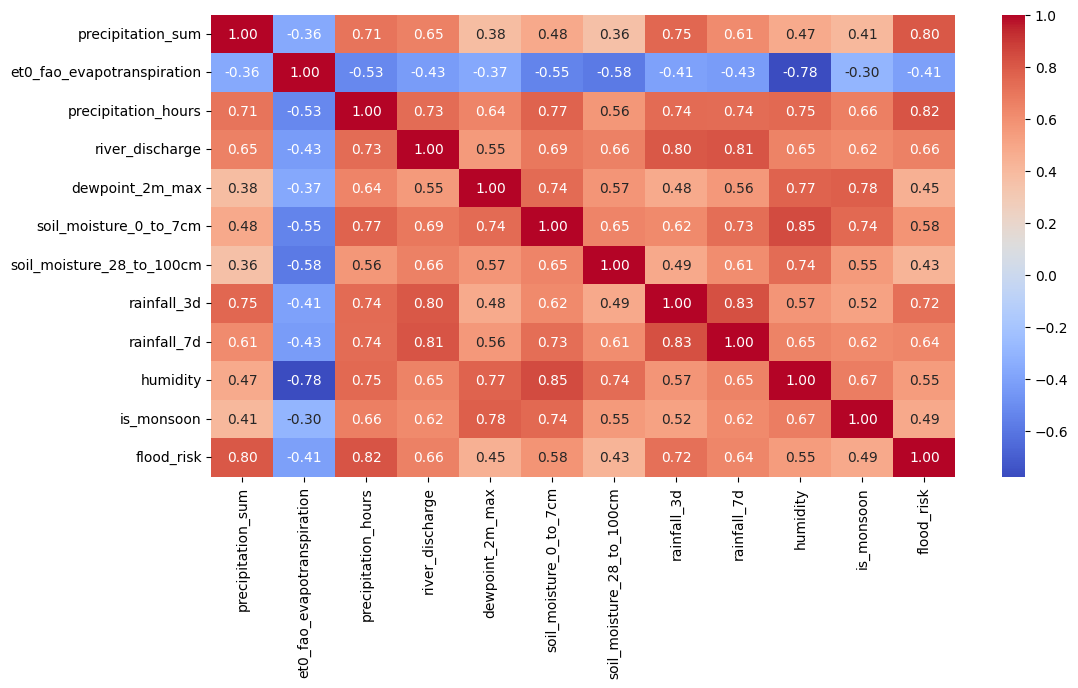

In [21]:
corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [22]:
df.drop(columns = ['time'], inplace=True)

In [23]:
df.corr() 

,precipitation_sum,et0_fao_evapotranspiration,precipitation_hours,river_discharge,dewpoint_2m_max,soil_moisture_0_to_7cm,soil_moisture_28_to_100cm,rainfall_3d,rainfall_7d,humidity,is_monsoon,flood_risk
precipitation_sum,1.000000,-0.362216,0.705652,0.654550,0.381173,0.484368,0.357044,0.753314,0.612403,0.474311,0.407234,0.800363
et0_fao_evapotranspiration,-0.362216,1.000000,-0.525589,-0.434044,-0.367539,-0.546902,-0.583912,-0.407601,-0.433948,-0.776749,-0.298789,-0.410239
precipitation_hours,0.705652,-0.525589,1.000000,0.731400,0.644382,0.767579,0.564038,0.741894,0.735332,0.745875,0.662631,0.817711
river_discharge,0.654550,-0.434044,0.731400,1.000000,0.553451,0.691953,0.656180,0.799468,0.813387,0.649895,0.619861,0.655395
dewpoint_2m_max,0.381173,-0.367539,0.644382,0.553451,1.000000,0.738875,0.572807,0.477243,0.558143,0.769339,0.784363,0.449483
soil_moisture_0_to_7cm,0.484368,-0.546902,0.767579,0.691953,0.738875,1.000000,0.645258,0.624924,0.725792,0.845526,0.744975,0.577205
soil_moisture_28_to_100cm,0.357044,-0.583912,0.564038,0.656180,0.572807,0.645258,1.000000,0.485555,0.608671,0.735336,0.550402,0.426855
rainfall_3d,0.753314,-0.407601,0.741894,0.799468,0.477243,0.624924,0.485555,1.000000,0.828549,0.572350,0.520931,0.718940
rainfall_7d,0.612403,-0.433948,0.735332,0.813387,0.558143,0.725792,0.608671,0.828549,1.000000,0.648931,0.621852,0.638321
humidity,0.474311,-0.776749,0.745875,0.649895,0.769339,0.845526,0.735336,0.572350,0.648931,1.000000,0.670363,0.545917


In [24]:
df.shape

(5864, 12)

In [25]:
df.head()

,precipitation_sum,et0_fao_evapotranspiration,precipitation_hours,river_discharge,dewpoint_2m_max,soil_moisture_0_to_7cm,soil_moisture_28_to_100cm,rainfall_3d,rainfall_7d,humidity,is_monsoon,flood_risk
0,0.0,3.92,0.0,0.20,12.5,0.232000,0.357042,0.0,0.0,28.0,0,0
1,0.0,4.20,0.0,0.20,11.9,0.231625,0.355583,0.0,0.0,25.0,0,0
2,0.0,3.71,0.0,0.23,11.7,0.231000,0.354542,0.0,0.0,26.0,0,0
3,0.0,3.26,0.0,0.25,11.7,0.231542,0.353542,0.0,0.0,31.0,0,0
4,0.0,3.97,0.0,0.25,11.0,0.232000,0.352542,0.0,0.0,24.0,0,0


In [26]:
df.to_csv("Flood_Preprocessed_Data.csv", index=False)